# Coin Detection System - Computer Vision Project
---

## Overview
This notebook detects and classifies coins in images using traditional computer vision techniques:
- **Circular Hough Transform** for circle detection
- **Size and Color analysis** for classification
- **No currency assumptions** - works for any coins worldwide

## Algorithm Pipeline
1. Load and preprocess image (grayscale + blur)
2. Detect circular shapes using Hough Transform
3. Extract features (radius, color) for each coin
4. Classify by size category and color
5. Group similar coins together
6. Visualize and summarize results

## Team Members
| Name                | ID      |
|---------------------|---------|
| Ahmed Hazem         | 22P0226 |
| Karim Hatem         | 22P0153 |
| Youssef Mostafa     | 22P0047 |
| Mostafa Foaad       | 22P0077 |
| AbdElRahman Mostafa | 22P0053 |

## Section 0 : Importing Libraries

In [89]:
import cv2
import os
import numpy as np
import math
from collections import Counter
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")
print(f"OpenCV version: {cv2.__version__}")

Libraries loaded successfully!
OpenCV version: 4.13.0


## Section 1 : Color Classification Functions
Defines coin colors (Silver, Gold, Copper, etc.)

Classify color based on HSV values

Parameters: hsv_color : tuple (Hue, Saturation, Value) values

Returns: (str) Color category name

In [90]:
# Section 1
def get_color_name(hsv_color):
    h, s, v = hsv_color

    # Very dark/black coins (some tokens, old coins)
    if v < 40:
        return "Dark/Black"

    # Silver/White coins (most modern coins: US quarters, dimes, Euro cents)
    if v > 180 and s < 40:
        return "Silver"

    # Gold/Brass coins (US dollars, some Euro coins, Arabic coins)
    if 15 <= h <= 35 and s > 40 and v > 100:
        return "Gold/Brass"

    # Copper/Bronze coins (US pennies, UK pennies, some Euro cents)
    if (h <= 15 or h >= 160) and s > 50 and v > 70:
        return "Copper/Bronze"

    # Nickel/Silver-gray tones (US nickels, some Euro coins)
    if 20 <= h <= 80 and s < 50 and v > 100:
        return "Nickel/Silver"

    # Yellowish coins (some commemorative coins, older gold-colored)
    if 25 <= h <= 45 and s > 40 and v > 120:
        return "Yellow/Gold"

    # Reddish-brown coins (very old copper coins, some tokens)
    if h <= 10 and s > 60 and 50 < v < 120:
        return "Reddish-Brown"

    # Gray coins (worn silver coins, some base metals)
    if s < 30 and 80 < v < 180:
        return "Gray"

    # Default for unusual coins
    return "Colored"

# Test the color function
test_colors = [
    (30, 100, 200),  # Should be Gold/Brass
    (10, 80, 150),   # Should be Copper/Bronze
    (60, 20, 220),   # Should be Silver
]

for hsv in test_colors:
    print(f"HSV {hsv} -> {get_color_name(hsv)}")

HSV (30, 100, 200) -> Gold/Brass
HSV (10, 80, 150) -> Copper/Bronze
HSV (60, 20, 220) -> Silver


## Section 2: Dynamic Size Classification

This section classifies coins relative to the distribution of all radii in the image. This **Scale-Independent** approach ensures accuracy regardless of camera distance.

### Logic
The system calculates limits dynamically for each image to separate clusters of Small, Medium, and Large coins.



### Function: `get_size_category`
**Parameters:**
* `radius` (int): Detected radius in pixels.
* `thresholds` (dict): Image-specific limits (`small_limit`, `medium_limit`).

| Category | Logic |
| :--- | :--- |
| **Small** | `radius < small_limit` |
| **Medium** | `small_limit <= radius < medium_limit` |
| **Large** | `radius >= medium_limit` |

In [91]:
def get_size_category(radius, thresholds):
    """Assigns category based on the image's dynamic math."""
    if not thresholds:
        return "Unknown"
    if radius < thresholds["small_limit"]:
        return "Small"
    elif radius < thresholds["medium_limit"]:
        return "Medium"
    else:
        return "Large"

## Section 2.5: Background Isolation

This section separates coins from the background using a multi-step pipeline combining intensity thresholding and color segmentation.

### Methodology
1. **Adaptive & Otsu Thresholding**: Combined to handle uneven lighting and global contrast.
2. **K-Means Clustering**: Clusters pixel colors to identify and mask the dominant background color.
3. **Morphological Operations**: Refines the mask by closing small holes and removing noise.

### Function: `isolate_coins_from_background`
**Returns**: A dictionary containing the binary threshold, the masked color image, and the final mask.

| Output Key | Description |
| :--- | :--- |
| `combined_thresh` | Weighted blend of Adaptive and Otsu binary images. |
| `coin_mask` | Cleaned binary mask representing coin locations. |
| `coins_extracted` | The original image with the background blacked out. |

In [92]:
## Section 2.5 : Background Isolation for Coin Detection

def isolate_coins_from_background(img):
    """
    Isolates coins from background using multiple techniques.
    Returns processed images for better detection.
    """
    h, w = img.shape[:2]

    # Convert to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Technique 1: Adaptive thresholding
    thresh_adapt = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                         cv2.THRESH_BINARY_INV, 25, 3)

    # Technique 2: Otsu thresholding
    _, thresh_otsu = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Technique 3: Combined threshold (best of both)
    combined_thresh = cv2.addWeighted(thresh_adapt, 0.5, thresh_otsu, 0.5, 0)

    # Technique 4: Color-based segmentation (remove dominant background color)
    pixels = img.reshape((-1, 3))
    pixels_float = np.float32(pixels)

    criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 20, 1.0)
    k = 3
    _, labels, centers = cv2.kmeans(pixels_float, k, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
    centers = np.uint8(centers)

    # Find background mask (most frequent color)
    label_counts = np.bincount(labels.flatten())
    bg_label = np.argmax(label_counts)
    bg_mask = (labels == bg_label).reshape(h, w).astype(np.uint8) * 255

    # Invert to get coin mask
    coin_mask = cv2.bitwise_not(bg_mask)

    # Morphological cleanup
    kernel_clean = np.ones((3,3), np.uint8)
    coin_mask = cv2.morphologyEx(coin_mask, cv2.MORPH_CLOSE, kernel_clean, iterations=2)
    coin_mask = cv2.morphologyEx(coin_mask, cv2.MORPH_OPEN, kernel_clean, iterations=1)

    # Extract coins from original using mask
    coins_extracted = cv2.bitwise_and(img, img, mask=coin_mask)

    return {
        'combined_thresh': combined_thresh,
        'coins_extracted': coins_extracted,
        'coin_mask': coin_mask
    }

## Section 3 : High-Precision Coin Detection

This section implements a robust detection pipeline using the **Hough Circle Transform** coupled with a custom "Ghost Filter" to eliminate false positives (hallucinations).

### Validation Strategy
To distinguish real coins from circular patterns in the background, the system performs two checks:
1. **Texture Variance**: Uses standard deviation to ensure the region isn't a flat, solid color.
2. **Edge Density**: Uses Canny edge detection to verify the presence of internal coin details (engravings/ridges).

### Function: `detect_coins_hough`
**Key Parameters**:
* `param1`: Sensitivity of the internal Canny edge detector.
* `param2`: Accumulator threshold; higher values ensure stricter circle matching.
* `dp`: Inverse ratio of the accumulator resolution to the image resolution.

| Step | Process | Goal |
| :--- | :--- | :--- |
| **1** | `preprocess_image` | Standardize scale for consistent radius detection. |
| **2** | `HoughCircles` | Identify potential circular candidates in the image. |
| **3** | `is_real_coin` | Filter candidates based on texture and edge density. |
| **4** | **Overlap Removal** | Consolidate multiple detections on a single coin into one result. |

In [93]:
def is_real_coin(roi_bgr):
    """
    Checks if a detected circular region has high edge density.
    This effectively filters out 'ghost' detections in smooth background areas.
    """
    if roi_bgr is None or roi_bgr.size == 0:
        return False

    # Convert ROI to grayscale
    gray_roi = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2GRAY)

    # 1. Texture Check: Standard Deviation
    # Coins have high variance due to ridges and engraving
    std_dev = np.std(gray_roi)
    if std_dev < 20: # Higher threshold for stricter filtering
        return False

    # 2. Edge Density Check:
    # Backgrounds are usually smooth. Coins have many internal edges.
    edges = cv2.Canny(gray_roi, 50, 150)
    edge_density = np.sum(edges > 0) / edges.size

    # If there is almost no 'detail' inside the circle, it's likely a hallucination
    return edge_density > 0.05

def preprocess_image(img, target_min_dim=800):
    """Resize image for consistent detection across different resolutions."""
    h, w = img.shape[:2]
    current_min = min(h, w)
    scale = target_min_dim / current_min

    if abs(1.0 - scale) > 0.1: # Only resize if the difference is significant
        new_w = int(w * scale)
        new_h = int(h * scale)
        return cv2.resize(img, (new_w, new_h)), scale
    return img, 1.0

def detect_coins_hough(image_path):
    """
    Detects coins using a high-precision Hough Circle Transform.
    Uses edge-density and variance filters to eliminate false positives.
    """
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not load image at {image_path}")
        return None, None

    original_img = img.copy()

    # 1. Preprocess for Detection
    # Note: We detect on the original color/gray image, NOT the isolated mask
    # to avoid false edges created by thresholding.
    work_img, scale = preprocess_image(img, target_min_dim=1000)
    gray = cv2.cvtColor(work_img, cv2.COLOR_BGR2GRAY)

    # Median Blur is excellent for removing salt-and-pepper noise while keeping edges
    blurred = cv2.medianBlur(gray, 11)

    # 2. Dynamic Parameters
    img_height, img_width = work_img.shape[:2]
    min_dim = min(img_height, img_width)

    min_radius = int(min_dim * 0.02)  # 2% of smallest dimension
    max_radius = int(min_dim * 0.25)  # 25% of smallest dimension
    min_dist = int(min_dim * 0.08)    # Prevents multiple detections on the same coin

    # 3. Apply Hough Circle Transform
    circles = cv2.HoughCircles(
        blurred,
        cv2.HOUGH_GRADIENT,
        dp=1.2,
        minDist=min_dist,
        param1=100,      # Higher = stricter Canny edge detection
        param2=85,       # CRITICAL: High value (70-90) reduces hallucinations
        minRadius=min_radius,
        maxRadius=max_radius
    )

    valid_circles = []

    if circles is not None:
        circles = np.round(circles[0, :]).astype("int")

        for (x, y, r) in circles:
            # 4. GHOST FILTER: Extract ROI from the ORIGINAL color image
            y1, y2 = max(0, y-r), min(work_img.shape[0], y+r)
            x1, x2 = max(0, x-r), min(work_img.shape[1], x+r)
            roi = work_img[y1:y2, x1:x2]

            if is_real_coin(roi):
                # Scale coordinates back to original image resolution
                orig_x = int(x / scale)
                orig_y = int(y / scale)
                orig_r = int(r / scale)
                valid_circles.append([orig_x, orig_y, orig_r])

    # 5. Overlap Removal (Non-Maximum Suppression)
    # If two circles are heavily overlapping, keep the larger one
    if valid_circles:
        valid_circles = sorted(valid_circles, key=lambda x: x[2], reverse=True)
        unique_circles = []
        for c in valid_circles:
            is_overlap = False
            for u in unique_circles:
                dist = math.sqrt((c[0]-u[0])**2 + (c[1]-u[1])**2)
                if dist < (u[2] * 0.8): # If center is inside 80% of an existing coin
                    is_overlap = True
                    break
            if not is_overlap:
                unique_circles.append(c)
        valid_circles = unique_circles

    print(f"Detected {len(valid_circles)} authentic coins.")
    return original_img, (np.array(valid_circles) if valid_circles else None)

## Section 4 : Feature Extraction

Extracts size and color features from each detected coin.

Parameters:
- original_image : numpy.ndarray (BGR image)
- circles : numpy.ndarray (detected circles)

Returns: list of dictionaries containing coin features (id, center, radius, diameter, color, size, etc.)

In [94]:
# Section 4 - Enhanced Feature Extraction
import math

def extract_coin_features(original_image, circles, thresholds):
    coin_features = []

    for i, (x, y, r) in enumerate(circles):
        # 1. Create a precise mask for the coin
        mask = np.zeros(original_image.shape[:2], dtype=np.uint8)
        cv2.circle(mask, (int(x), int(y)), int(r), 255, -1)

        # 2. Calculate color in HSV space
        mean_bgr = cv2.mean(original_image, mask=mask)[:3]
        mean_bgr_uint8 = np.uint8([[mean_bgr]])
        mean_hsv = cv2.cvtColor(mean_bgr_uint8, cv2.COLOR_BGR2HSV)[0][0]

        # 3. Build the feature dictionary with all expected keys
        coin_features.append({
            'id': i + 1,
            'center': (int(x), int(y)),
            'radius': int(r),
            'diameter_pixels': int(r * 2), # Required for print_summary
            'area_pixels': math.pi * (r ** 2),
            'color': get_color_name(mean_hsv),
            'size': get_size_category(r, thresholds), # Dynamic classification
            'bgr': mean_bgr,
            'hsv': mean_hsv
        })

    return coin_features

## Section 5 : Coin Grouping

Groups coins that share the same size category AND color.

Parameters: coins : list (coin features from Section 5)

Returns: list of groups with group ID, count, size, color, and average measurements

In [95]:
# Section 5 - Dynamic Grouping with Statistics
def group_similar_coins(coins):
    groups_dict = {}

    for coin in coins:
        # Group by the unique combination of Color and Dynamic Size
        group_key = f"{coin['color']}_{coin['size']}"

        if group_key not in groups_dict:
            groups_dict[group_key] = {
                'id': len(groups_dict) + 1,
                'count': 0,
                'coins': [],
                'color': coin['color'],
                'size': coin['size']
            }

        groups_dict[group_key]['count'] += 1
        groups_dict[group_key]['coins'].append(coin)

    # Calculate statistical averages for each group
    final_groups = []
    for key in groups_dict:
        group = groups_dict[key]
        group['avg_radius'] = np.mean([c['radius'] for c in group['coins']])
        group['avg_diameter'] = np.mean([c['diameter_pixels'] for c in group['coins']])
        final_groups.append(group)

    # Sort groups by coin count (most frequent first)
    final_groups.sort(key=lambda x: x['count'], reverse=True)
    return final_groups

## Section 6 : Image Annotation

Draws results on the image. Circle colors are chosen from realistic metallic/coin colors (no pink, magenta, cyan, etc.)

Parameters:
- image : numpy.ndarray (image to annotate)
- coins : list (coin features)
- groups : list (coin groups)

Returns: annotated image

In [96]:
# Section 6
def annotate_image(image, coins, groups):
    # Realistic colors that might appear on coins or currency
    group_colors = [
        (192, 192, 192),  # Silver
        (218, 165, 32),   # Goldenrod
        (205, 127, 50),   # Copper
        (169, 169, 169),  # Dark Gray
        (255, 215, 0),    # Gold
        (210, 105, 30),   # Bronze
        (128, 128, 128),  # Gray
        (238, 232, 170),  # Pale Goldenrod
        (184, 115, 51),   # Peru (brownish-gold)
        (192, 192, 192),  # Light Silver
    ]

    group_color_map = {}
    for i, group in enumerate(groups):
        group_color_map[group['id']] = group_colors[i % len(group_colors)]

    for coin in coins:
        x, y = coin['center']
        r = coin['radius']

        group_id = None
        for group in groups:
            if coin in group['coins']:
                group_id = group['id']
                break

        if group_id:
            color = group_color_map[group_id]

            cv2.circle(image, (x, y), r, color, 4)
            cv2.circle(image, (x, y), 3, color, -1)

            label = f"G{group_id}: {coin['color']}, {coin['size']}"
            text_x, text_y = x - r, y - r - 10

            (text_w, text_h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            cv2.rectangle(image, (text_x - 5, text_y - text_h - 5),
                         (text_x + text_w + 5, text_y + 5), (0, 0, 0), -1)
            cv2.rectangle(image, (text_x - 5, text_y - text_h - 5),
                         (text_x + text_w + 5, text_y + 5), color, 2)
            cv2.putText(image, label, (text_x, text_y),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

    return image

## Section 7 : Results Summary

Prints formatted summary to console and creates statistics image.

Parameters: coins, groups (from previous sections)

Returns: None (prints to console and saves image)

In [97]:
# Section 7
def print_summary(coins, groups):
    print("\n" + "="*60)
    print("COIN DETECTION & CLASSIFICATION SUMMARY")
    print("="*60)
    print(f"\n📊 TOTAL: {len(coins)} coins detected\n")

    print("📋 CLASSIFICATION BY GROUPS:")
    print("-"*60)
    for group in groups:
        print(f"\n GROUP {group['id']}: {group['count']} coins")
        print(f"      Size: {group['size']}")
        print(f"      Color: {group['color']}")
        print(f"      Avg Diameter: {group['avg_diameter']:.1f} pixels")
        print(f"      Coin IDs: {[c['id'] for c in group['coins']]}")

    print("\n" + "-"*60)
    color_counts = Counter([c['color'] for c in coins])
    print("\n🎨 By Color:")
    for color, count in color_counts.most_common():
        print(f"   {color:15s}: {count:2d} coins ({count/len(coins)*100:.1f}%)")

    size_counts = Counter([c['size'] for c in coins])
    print("\n📏 By Size:")
    for size, count in size_counts.most_common():
        print(f"   {size:12s}: {count:2d} coins ({count/len(coins)*100:.1f}%)")

    print("\n" + "="*60)

def create_stats_image(coins, groups):
    stats_img = np.zeros((600, 500, 3), dtype=np.uint8)
    y = 50

    cv2.putText(stats_img, "CLASSIFICATION STATISTICS", (50, y),
               cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
    y += 70

    cv2.putText(stats_img, f"Total Coins: {len(coins)}", (50, y),
               cv2.FONT_HERSHEY_SIMPLEX, 0.7, (100, 255, 100), 2)
    y += 40

    cv2.putText(stats_img, "Groups Found:", (50, y),
               cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 200, 100), 2)
    y += 30

    for group in groups[:8]:
        text = f"Group {group['id']}: {group['count']} coins - {group['color']}, {group['size']}"
        cv2.putText(stats_img, text, (70, y),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 200), 1)
        y += 25

    return stats_img

## Section 8: Automated Folder Processing & Extraction

This final section automates the entire pipeline, processing all images in a source folder and organizing the results into structured subdirectories.

### Automation Workflow
1. **Batch Loading**: Scans the `data` folder for supported image formats.
2. **Feature Extraction & Grouping**: Detects coins, calculates relative size thresholds, and groups coins by similar physical characteristics.
3. **Multi-Format Export**:
    * **Cropped Images**: Saves each coin as an individual PNG.
    * **Masked Assets**: Saves coins with backgrounds removed for dataset creation.
    * **Visual Reports**: Generates a statistical chart and an annotated summary for every image.

### Directory Structure
```text
output/
└── image_name/
    ├── _statistics.jpg        (Charts & totals)
    ├── _summary_annotated.jpg (Visual detection map)
    ├── coin_1_gold_large.png  (Individual crop)
    └── coin_1_gold_large_masked.png


--- Processing: Coins_1.jpg ---
Detected 30 authentic coins.

COIN DETECTION & CLASSIFICATION SUMMARY

📊 TOTAL: 30 coins detected

📋 CLASSIFICATION BY GROUPS:
------------------------------------------------------------

 GROUP 3: 5 coins
      Size: Large
      Color: Gold/Brass
      Avg Diameter: 229.6 pixels
      Coin IDs: [3, 4, 7, 8, 10]

 GROUP 5: 5 coins
      Size: Medium
      Color: Gold/Brass
      Avg Diameter: 205.6 pixels
      Coin IDs: [12, 15, 16, 17, 19]

 GROUP 13: 4 coins
      Size: Small
      Color: Copper/Bronze
      Avg Diameter: 160.0 pixels
      Coin IDs: [24, 25, 28, 30]

 GROUP 2: 3 coins
      Size: Large
      Color: Silver
      Avg Diameter: 239.3 pixels
      Coin IDs: [2, 5, 11]

 GROUP 1: 2 coins
      Size: Large
      Color: Nickel/Silver
      Avg Diameter: 256.0 pixels
      Coin IDs: [1, 6]

 GROUP 10: 2 coins
      Size: Small
      Color: Nickel/Silver
      Avg Diameter: 174.0 pixels
      Coin IDs: [21, 27]

 GROUP 11: 2 coins
      Siz

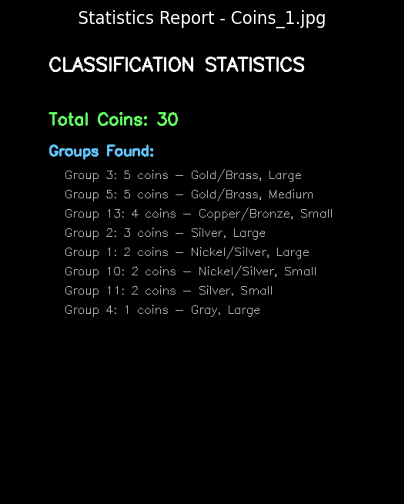

  ✓ Saved 30 cropped coins to output\Coins_1/


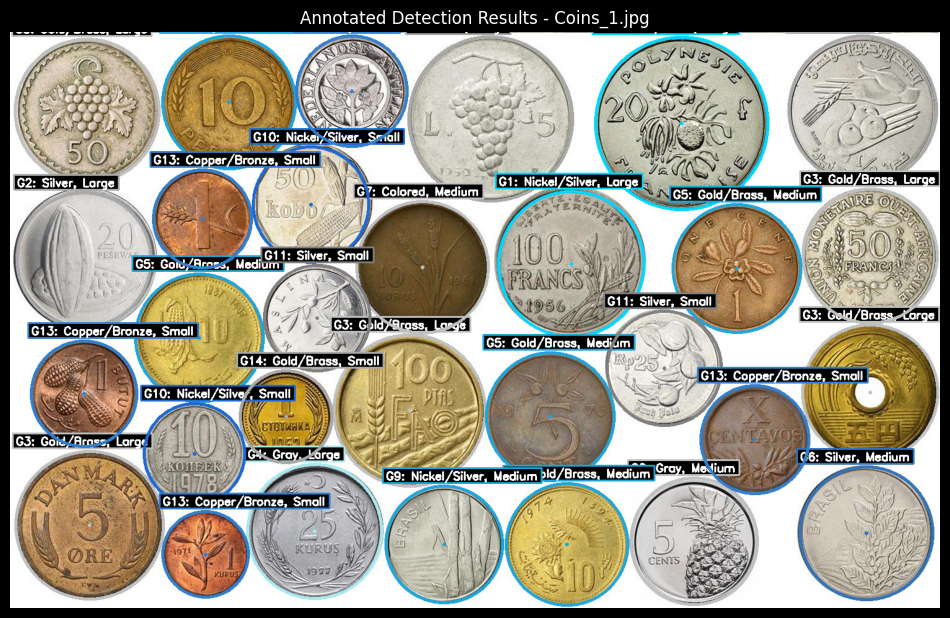


--- Processing: Coins_2.jpg ---
Detected 54 authentic coins.

COIN DETECTION & CLASSIFICATION SUMMARY

📊 TOTAL: 54 coins detected

📋 CLASSIFICATION BY GROUPS:
------------------------------------------------------------

 GROUP 1: 14 coins
      Size: Large
      Color: Gold/Brass
      Avg Diameter: 250.9 pixels
      Coin IDs: [1, 4, 5, 6, 7, 8, 10, 11, 15, 16, 17, 18, 19, 20]

 GROUP 6: 9 coins
      Size: Medium
      Color: Gold/Brass
      Avg Diameter: 216.2 pixels
      Coin IDs: [24, 26, 27, 29, 30, 32, 33, 34, 35]

 GROUP 9: 9 coins
      Size: Small
      Color: Gold/Brass
      Avg Diameter: 177.3 pixels
      Coin IDs: [37, 39, 40, 42, 44, 49, 50, 51, 54]

 GROUP 3: 4 coins
      Size: Large
      Color: Nickel/Silver
      Avg Diameter: 251.0 pixels
      Coin IDs: [3, 12, 13, 14]

 GROUP 5: 3 coins
      Size: Medium
      Color: Silver
      Avg Diameter: 214.7 pixels
      Coin IDs: [23, 31, 36]

 GROUP 10: 3 coins
      Size: Small
      Color: Copper/Bronze
      Av

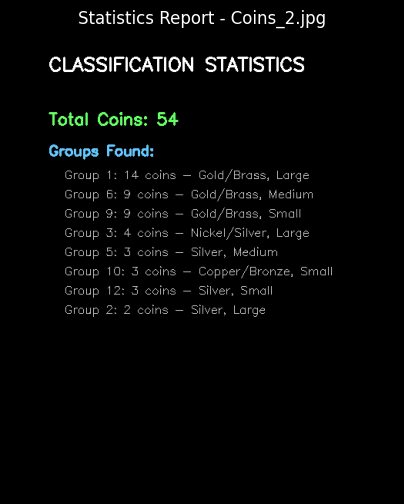

  ✓ Saved 54 cropped coins to output\Coins_2/


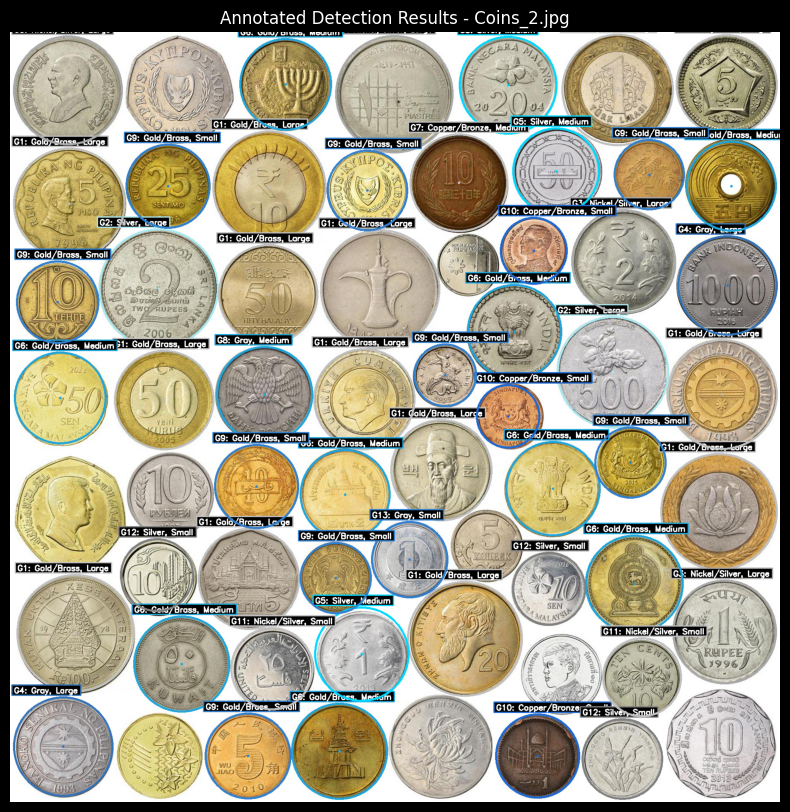


--- Processing: Coins_3.jpg ---
Detected 24 authentic coins.

COIN DETECTION & CLASSIFICATION SUMMARY

📊 TOTAL: 24 coins detected

📋 CLASSIFICATION BY GROUPS:
------------------------------------------------------------

 GROUP 3: 4 coins
      Size: Large
      Color: Silver
      Avg Diameter: 205.0 pixels
      Coin IDs: [4, 6, 7, 8]

 GROUP 1: 3 coins
      Size: Large
      Color: Gold/Brass
      Avg Diameter: 216.0 pixels
      Coin IDs: [1, 2, 5]

 GROUP 7: 3 coins
      Size: Medium
      Color: Copper/Bronze
      Avg Diameter: 169.3 pixels
      Coin IDs: [13, 16, 17]

 GROUP 9: 3 coins
      Size: Small
      Color: Gold/Brass
      Avg Diameter: 156.0 pixels
      Coin IDs: [19, 21, 22]

 GROUP 4: 2 coins
      Size: Medium
      Color: Gold/Brass
      Avg Diameter: 192.0 pixels
      Coin IDs: [9, 11]

 GROUP 5: 2 coins
      Size: Medium
      Color: Gray
      Avg Diameter: 183.0 pixels
      Coin IDs: [10, 15]

 GROUP 6: 2 coins
      Size: Medium
      Color: Silver

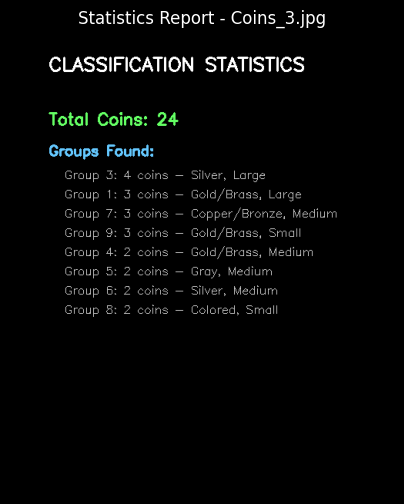

  ✓ Saved 24 cropped coins to output\Coins_3/


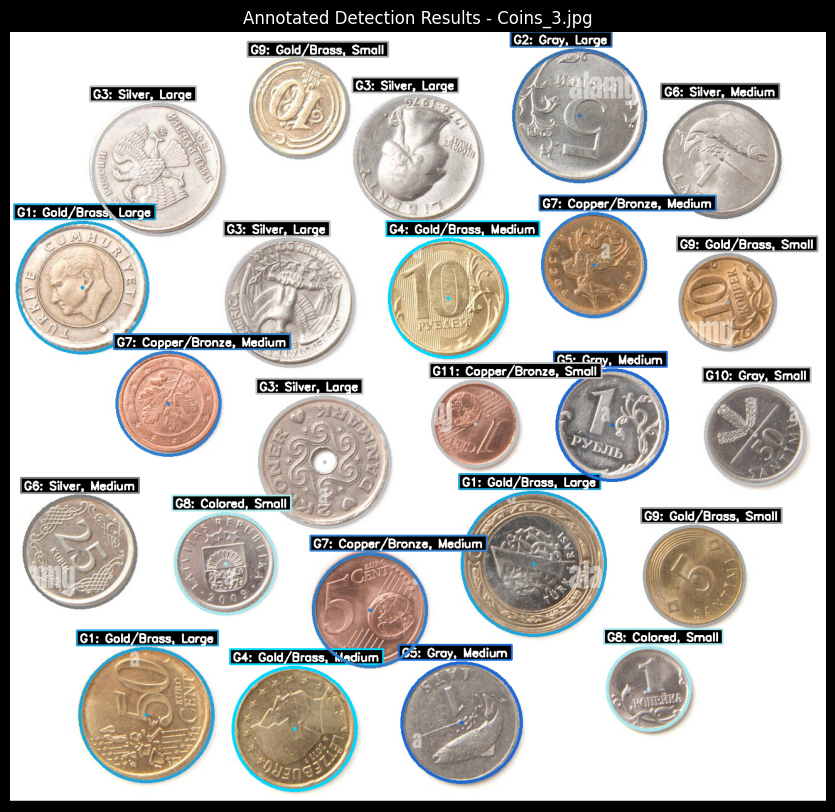


--- Processing: Coins_4.jpg ---
Detected 28 authentic coins.

COIN DETECTION & CLASSIFICATION SUMMARY

📊 TOTAL: 28 coins detected

📋 CLASSIFICATION BY GROUPS:
------------------------------------------------------------

 GROUP 7: 5 coins
      Size: Medium
      Color: Copper/Bronze
      Avg Diameter: 138.4 pixels
      Coin IDs: [13, 16, 17, 18, 19]

 GROUP 3: 4 coins
      Size: Large
      Color: Gray
      Avg Diameter: 165.5 pixels
      Coin IDs: [3, 5, 8, 9]

 GROUP 8: 4 coins
      Size: Small
      Color: Copper/Bronze
      Avg Diameter: 122.0 pixels
      Coin IDs: [20, 23, 27, 28]

 GROUP 6: 3 coins
      Size: Medium
      Color: Gray
      Avg Diameter: 143.3 pixels
      Coin IDs: [12, 14, 15]

 GROUP 9: 3 coins
      Size: Small
      Color: Gold/Brass
      Avg Diameter: 123.3 pixels
      Coin IDs: [21, 25, 26]

 GROUP 1: 2 coins
      Size: Large
      Color: Gold/Brass
      Avg Diameter: 179.0 pixels
      Coin IDs: [1, 6]

 GROUP 2: 2 coins
      Size: Large
  

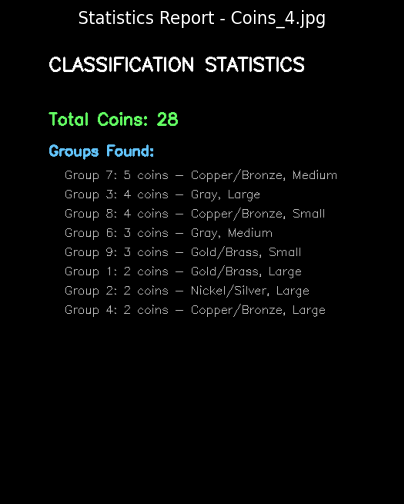

  ✓ Saved 28 cropped coins to output\Coins_4/


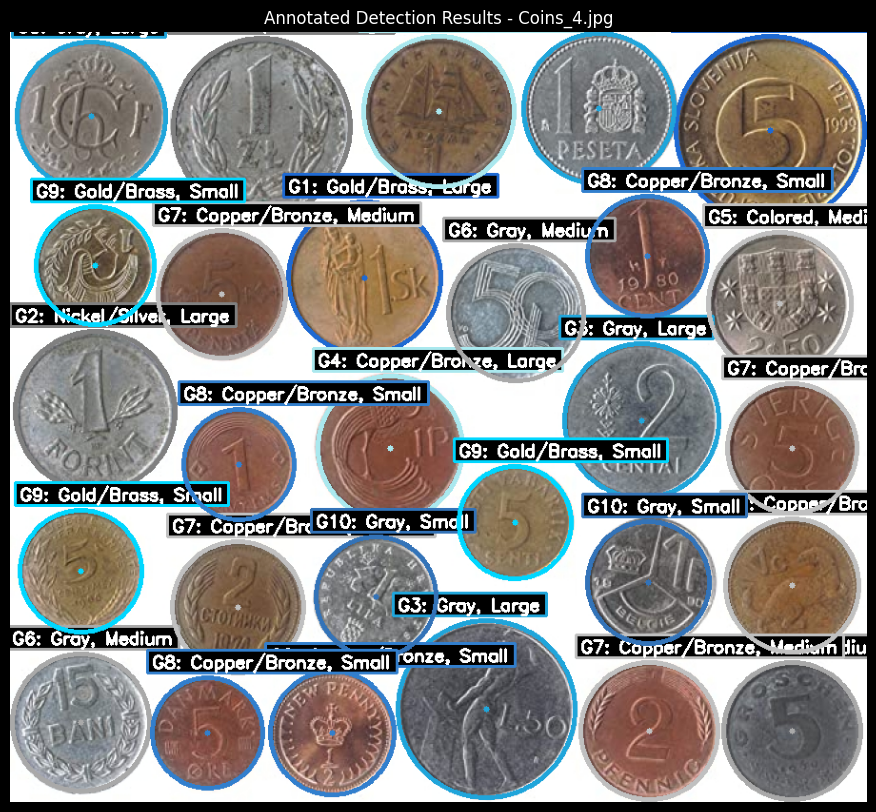


--- Processing: Coins_5.jpeg ---
Detected 5 authentic coins.

COIN DETECTION & CLASSIFICATION SUMMARY

📊 TOTAL: 5 coins detected

📋 CLASSIFICATION BY GROUPS:
------------------------------------------------------------

 GROUP 1: 1 coins
      Size: Large
      Color: Colored
      Avg Diameter: 216.0 pixels
      Coin IDs: [1]

 GROUP 2: 1 coins
      Size: Large
      Color: Silver
      Avg Diameter: 206.0 pixels
      Coin IDs: [2]

 GROUP 3: 1 coins
      Size: Medium
      Color: Nickel/Silver
      Avg Diameter: 200.0 pixels
      Coin IDs: [3]

 GROUP 4: 1 coins
      Size: Small
      Color: Gold/Brass
      Avg Diameter: 182.0 pixels
      Coin IDs: [4]

 GROUP 5: 1 coins
      Size: Small
      Color: Gray
      Avg Diameter: 168.0 pixels
      Coin IDs: [5]

------------------------------------------------------------

🎨 By Color:
   Colored        :  1 coins (20.0%)
   Silver         :  1 coins (20.0%)
   Nickel/Silver  :  1 coins (20.0%)
   Gold/Brass     :  1 coins (20.

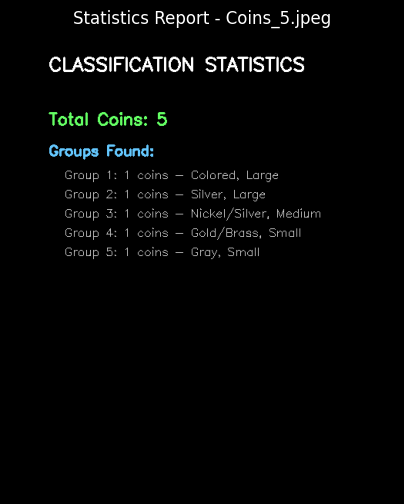

  ✓ Saved 5 cropped coins to output\Coins_5/


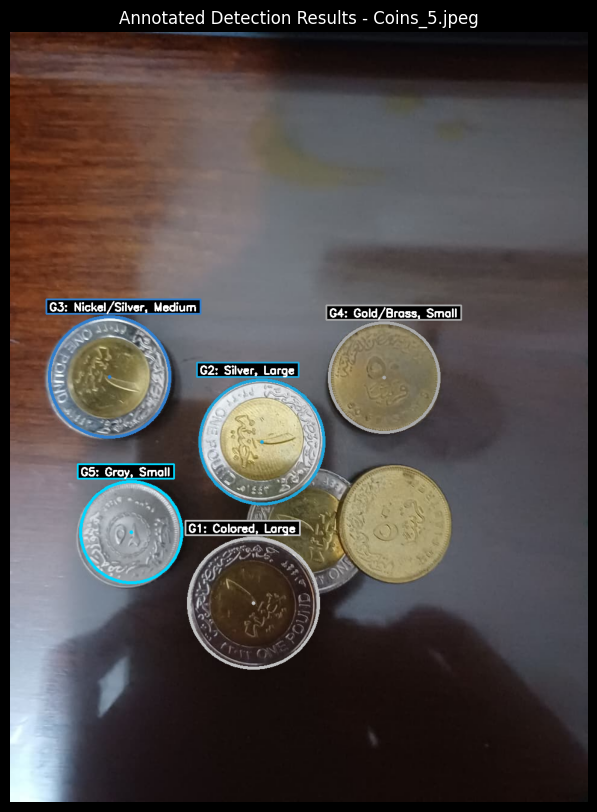


--- Processing: Coins_6.jpg ---
Detected 2 authentic coins.

COIN DETECTION & CLASSIFICATION SUMMARY

📊 TOTAL: 2 coins detected

📋 CLASSIFICATION BY GROUPS:
------------------------------------------------------------

 GROUP 1: 1 coins
      Size: Large
      Color: Silver
      Avg Diameter: 58.0 pixels
      Coin IDs: [1]

 GROUP 2: 1 coins
      Size: Small
      Color: Silver
      Avg Diameter: 56.0 pixels
      Coin IDs: [2]

------------------------------------------------------------

🎨 By Color:
   Silver         :  2 coins (100.0%)

📏 By Size:
   Large       :  1 coins (50.0%)
   Small       :  1 coins (50.0%)



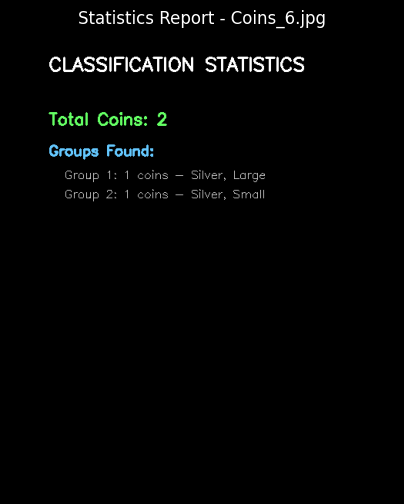

  ✓ Saved 2 cropped coins to output\Coins_6/


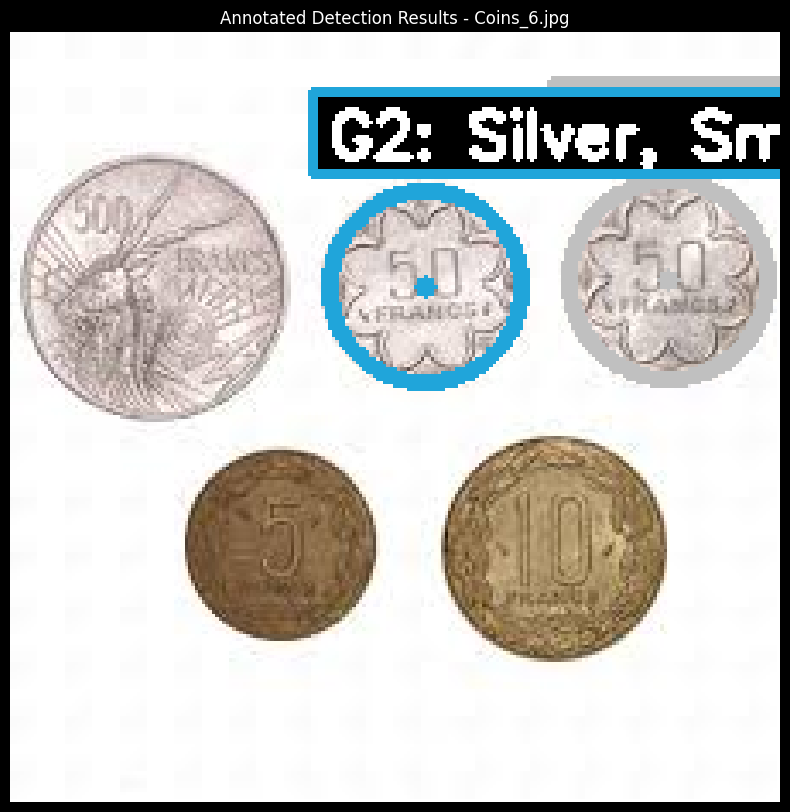


--- Processing: Coins_7.jpg ---
Detected 7 authentic coins.

COIN DETECTION & CLASSIFICATION SUMMARY

📊 TOTAL: 7 coins detected

📋 CLASSIFICATION BY GROUPS:
------------------------------------------------------------

 GROUP 1: 2 coins
      Size: Large
      Color: Silver
      Avg Diameter: 108.0 pixels
      Coin IDs: [1, 2]

 GROUP 5: 2 coins
      Size: Small
      Color: Silver
      Avg Diameter: 58.0 pixels
      Coin IDs: [6, 7]

 GROUP 2: 1 coins
      Size: Large
      Color: Gold/Brass
      Avg Diameter: 90.0 pixels
      Coin IDs: [3]

 GROUP 3: 1 coins
      Size: Medium
      Color: Gold/Brass
      Avg Diameter: 88.0 pixels
      Coin IDs: [4]

 GROUP 4: 1 coins
      Size: Medium
      Color: Silver
      Avg Diameter: 80.0 pixels
      Coin IDs: [5]

------------------------------------------------------------

🎨 By Color:
   Silver         :  5 coins (71.4%)
   Gold/Brass     :  2 coins (28.6%)

📏 By Size:
   Large       :  3 coins (42.9%)
   Medium      :  2 coin

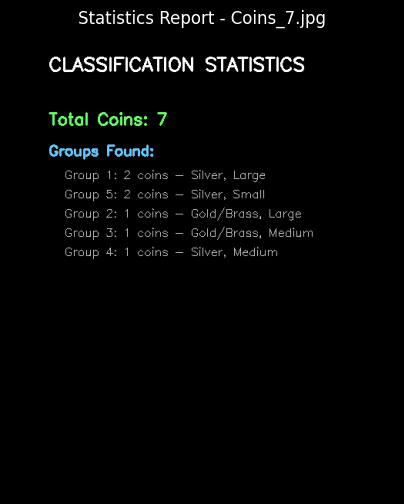

  ✓ Saved 7 cropped coins to output\Coins_7/


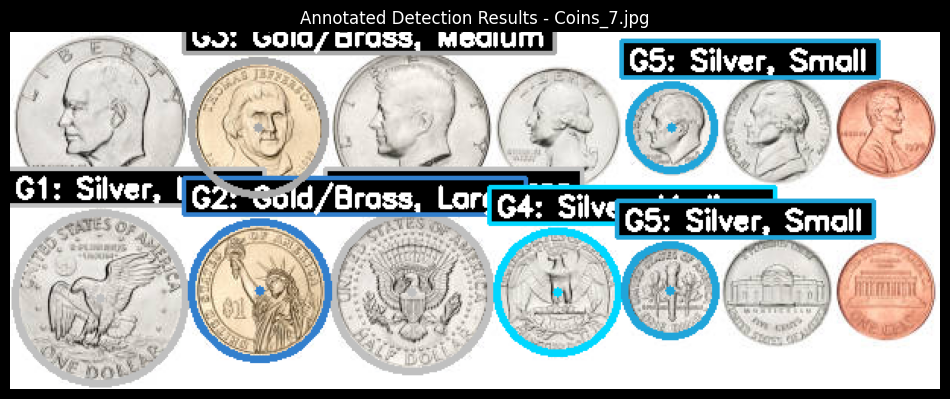


--- Processing: Coins_8.jpeg ---
Detected 6 authentic coins.

COIN DETECTION & CLASSIFICATION SUMMARY

📊 TOTAL: 6 coins detected

📋 CLASSIFICATION BY GROUPS:
------------------------------------------------------------

 GROUP 1: 2 coins
      Size: Large
      Color: Gold/Brass
      Avg Diameter: 364.0 pixels
      Coin IDs: [1, 2]

 GROUP 2: 1 coins
      Size: Medium
      Color: Gold/Brass
      Avg Diameter: 350.0 pixels
      Coin IDs: [3]

 GROUP 3: 1 coins
      Size: Medium
      Color: Colored
      Avg Diameter: 344.0 pixels
      Coin IDs: [4]

 GROUP 4: 1 coins
      Size: Small
      Color: Colored
      Avg Diameter: 334.0 pixels
      Coin IDs: [5]

 GROUP 5: 1 coins
      Size: Small
      Color: Gold/Brass
      Avg Diameter: 314.0 pixels
      Coin IDs: [6]

------------------------------------------------------------

🎨 By Color:
   Gold/Brass     :  4 coins (66.7%)
   Colored        :  2 coins (33.3%)

📏 By Size:
   Large       :  2 coins (33.3%)
   Medium      :

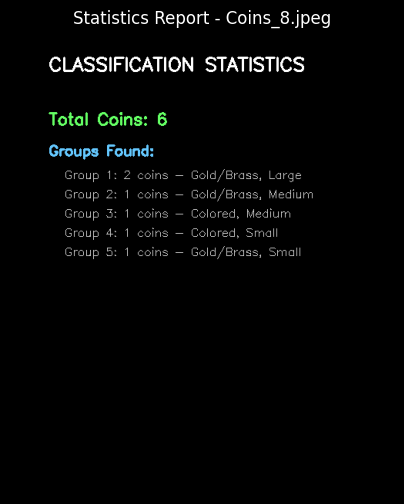

  ✓ Saved 6 cropped coins to output\Coins_8/


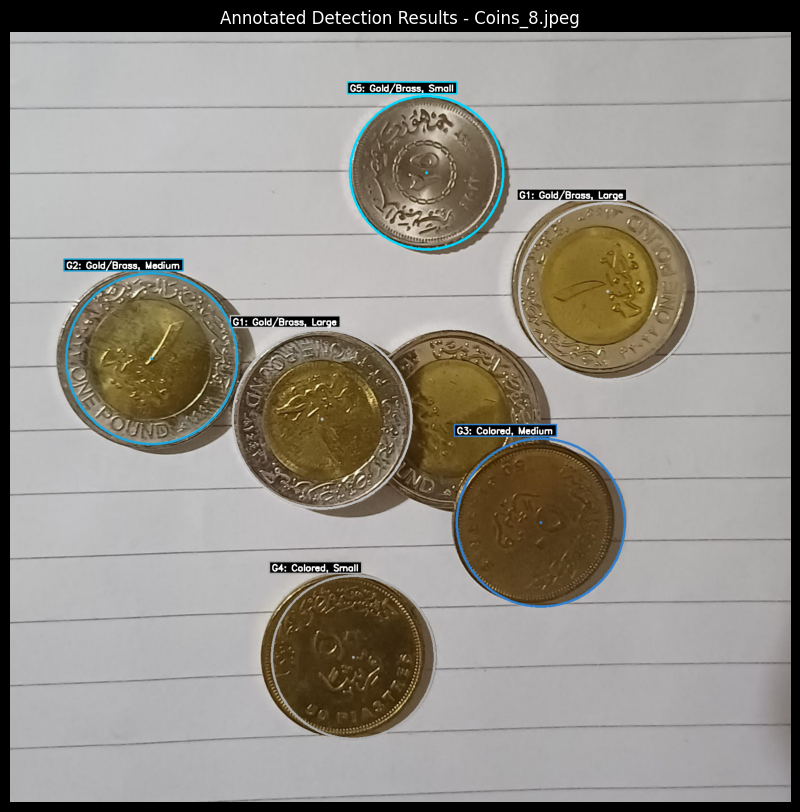


--- Processing: Coins_9.jpeg ---
Detected 5 authentic coins.

COIN DETECTION & CLASSIFICATION SUMMARY

📊 TOTAL: 5 coins detected

📋 CLASSIFICATION BY GROUPS:
------------------------------------------------------------

 GROUP 1: 2 coins
      Size: Large
      Color: Gold/Brass
      Avg Diameter: 435.0 pixels
      Coin IDs: [1, 2]

 GROUP 2: 1 coins
      Size: Medium
      Color: Gold/Brass
      Avg Diameter: 428.0 pixels
      Coin IDs: [3]

 GROUP 3: 1 coins
      Size: Small
      Color: Colored
      Avg Diameter: 424.0 pixels
      Coin IDs: [4]

 GROUP 4: 1 coins
      Size: Small
      Color: Gold/Brass
      Avg Diameter: 416.0 pixels
      Coin IDs: [5]

------------------------------------------------------------

🎨 By Color:
   Gold/Brass     :  4 coins (80.0%)
   Colored        :  1 coins (20.0%)

📏 By Size:
   Large       :  2 coins (40.0%)
   Small       :  2 coins (40.0%)
   Medium      :  1 coins (20.0%)



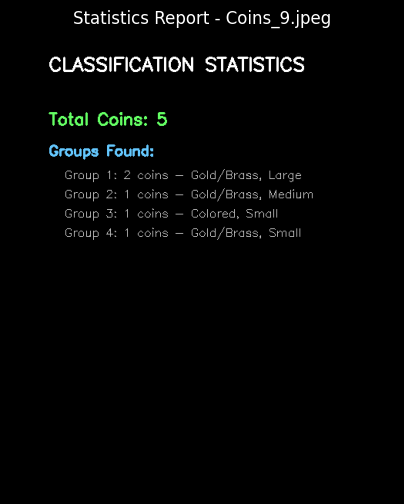

  ✓ Saved 5 cropped coins to output\Coins_9/


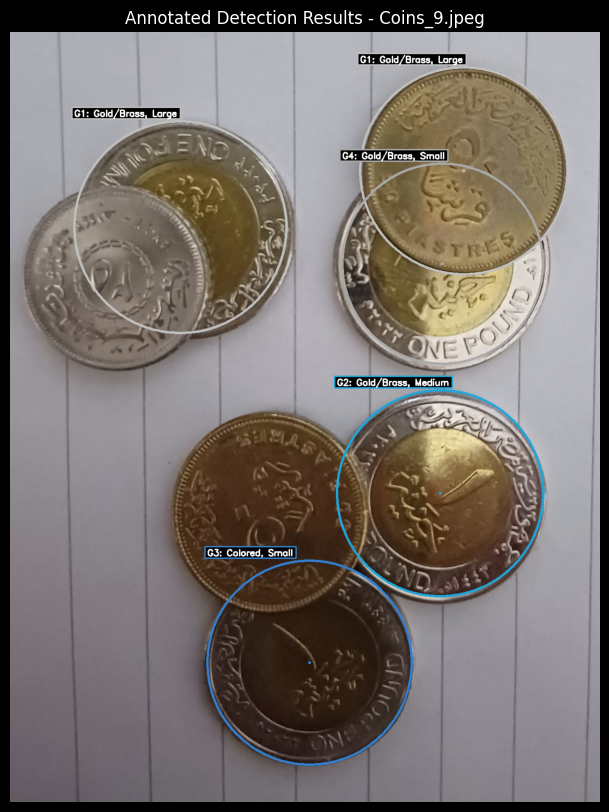

In [98]:
input_folder = "data"
output_folder = "output"
os.makedirs(output_folder, exist_ok=True)

valid_exts = (".jpg", ".jpeg", ".png")
images = [f for f in os.listdir(input_folder) if f.lower().endswith(valid_exts)]

# Choose detection method:
# detect_coins_hough - Preferred (uses Hough Circles)
# detect_coins_contours - Backup (uses Contours)
DETECTION_FUNCTION = detect_coins_hough

for filename in images:
    path = os.path.join(input_folder, filename)
    print(f"\n--- Processing: {filename} ---")

    # Detect coins using selected method
    img, circles = DETECTION_FUNCTION(path)

    if circles is not None and len(circles) > 0:
        img_name = os.path.splitext(filename)[0]
        img_dir = os.path.join(output_folder, img_name)
        os.makedirs(img_dir, exist_ok=True)

        # Calculate dynamic thresholds
        coin_list = [{'radius': c[2]} for c in circles]
        thresholds = get_dynamic_thresholds(coin_list)

        # Extract Features
        features = extract_coin_features(img, circles, thresholds)

        # Group similar coins
        groups = group_similar_coins(features)

        # 1. Print Text Summary
        print_summary(features, groups)

        # 2. Generate, Save, and DISPLAY Statistics Image
        stats_img = create_stats_image(features, groups)
        cv2.imwrite(os.path.join(img_dir, "_statistics.jpg"), stats_img)

        plt.figure(figsize=(12, 6))
        plt.imshow(cv2.cvtColor(stats_img, cv2.COLOR_BGR2RGB))
        plt.title(f"Statistics Report - {filename}")
        plt.axis('off')
        plt.show()

        # Extract and save individual coins
        for i, coin in enumerate(features):
            x, y = coin['center']
            r = coin['radius']

            pad = int(r * 0.15)
            y1, y2 = max(0, y - r - pad), min(img.shape[0], y + r + pad)
            x1, x2 = max(0, x - r - pad), min(img.shape[1], x + r + pad)

            coin_crop = img[y1:y2, x1:x2]

            if coin_crop.size > 0:
                h, w = coin_crop.shape[:2]
                filename_coin = f"coin_{i+1}_{coin['color']}_{coin['size']}_r{coin['radius']}px.png"
                cv2.imwrite(os.path.join(img_dir, filename_coin), coin_crop)

                mask = np.zeros((h, w), dtype=np.uint8)
                cv2.circle(mask, (min(x - x1, w-1), min(y - y1, h-1)), r, 255, -1)

                masked_coin = cv2.bitwise_and(coin_crop, coin_crop, mask=mask)
                masked_filename = f"coin_{i+1}_{coin['color']}_{coin['size']}_masked.png"
                cv2.imwrite(os.path.join(img_dir, masked_filename), masked_coin)

        print(f"  ✓ Saved {len(features)} cropped coins to {img_dir}/")

        # 3. Annotate, Save, and DISPLAY Final Annotated Image
        processed_img = annotate_image(img.copy(), features, groups)
        cv2.imwrite(os.path.join(img_dir, "_summary_annotated.jpg"), processed_img)

        plt.figure(figsize=(12, 10))
        plt.imshow(cv2.cvtColor(processed_img, cv2.COLOR_BGR2RGB))
        plt.title(f"Annotated Detection Results - {filename}")
        plt.axis('off')
        plt.show()

    else:
        print(f"  ✗ No coins detected in {filename}")